# 05 — Autoencoders

**Dataset:** `aim_2023`

**Question:** Does nonlinear reconstruction beat equal-dimension PCA?

## Method

Train compact autoencoder on training windows. Compare held-out error with PCA fit on same split.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "lap_estimation").exists():
    ROOT = ROOT.parent
if not (ROOT / "lap_estimation").exists():
    raise FileNotFoundError("Repository root not found")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lap_estimation.plotting_learned import render_autoencoder_diagnostics
from lap_estimation.artifacts import load_experiment_metrics
from lap_estimation.config import RANDOM_SEED
from lap_estimation.data import prepare_recording_manifest
from lap_estimation.datasets import resolve_dataset
from lap_estimation.runners import run_experiment

DATASET_KEY = "aim_2023"
dataset = resolve_dataset(DATASET_KEY, ROOT)
ARTIFACT_ROOT = dataset.artifact_root
np.random.seed(RANDOM_SEED)
sns.set_theme(style="ticks", palette="colorblind", context="notebook")
manifest = prepare_recording_manifest(dataset)
manifest[["recording_id", "duration_s", "motion_status", "control_candidate", "clock_provenance", "split"]]

,recording_id,duration_s,motion_status,control_candidate,clock_provenance,split
0,18385fe48224fbfa0cd6d17705d9305f857d70ef07b47b...,228.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
1,27937681c8199780c6cbce603f217d5a4457c351e84fa3...,217.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
2,4975a35d789765b9299480af66d6a5af5166fef074cef8...,210.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
3,5790cd1534b1de5ac4693367fe5d8ca6951cd36a7abcd3...,25.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
4,5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba7...,89.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
5,5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3...,33.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
6,6732a35a8f6343dcf041f1a3ad40d6760331513a2556c4...,21.95,dynamic_candidate,False,inferred_uniform_from_metadata,train
7,7208a43e77536a72e401c00f01a793130fb6688d28fb80...,9.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
8,73093667f33a7f710fc20059989a002071359119e1e9c0...,10.95,low_dynamics_candidate,True,inferred_uniform_from_metadata,train
9,8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe3...,107.95,dynamic_candidate,False,inferred_uniform_from_metadata,train


In [2]:
EXPERIMENT_OPTIONS = {'epochs': 25}
EXPERIMENT_OPTIONS

{'epochs': 25}

,task,split,metric,value,sample_count,reference_source
0,window_reconstruction,train,autoencoder_mse,16.333256,662,none
1,window_reconstruction,validation,autoencoder_mse,49.383200,61,none
2,window_reconstruction,test,autoencoder_mse,9.359964,213,none
3,window_reconstruction,all,autoencoder_mse,16.900281,936,none
4,window_reconstruction,train,pca_mse,16.667065,662,none
5,window_reconstruction,validation,pca_mse,45.459167,61,none
6,window_reconstruction,test,pca_mse,9.046168,213,none
7,window_reconstruction,all,pca_mse,16.809231,936,none


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recording_id,936,18,9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e72...,224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment_id,936,936,window_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_s,936.0,NaN,NaN,NaN,118.839744,101.772946,0.0,40.0,94.0,168.0,446.0
end_s,936.0,NaN,NaN,NaN,128.839744,101.772946,10.0,50.0,104.0,178.0,456.0
prediction_kind,936,1,autoencoder_reconstruction_error,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,936.0,NaN,NaN,NaN,16.900281,27.076033,0.025472,0.107658,0.5809,30.453255,145.930462
label_status,936,1,provisional_unverified,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pca_reconstruction_error,936.0,NaN,NaN,NaN,16.809231,26.827306,0.072061,0.167869,0.558628,28.838036,126.389133


,count,mean,median,std,min,max
recording_id,,,,,,
b185f43818b8ff3aba325752922bbbf37fd094f1e282887487651e0a5c8f6c7a,58,51.778470,53.689896,40.987697,0.257094,129.756952
8f799d59c9b5348ece1e5671692ea783d6d5e450ccebe31b6db9ad4f9510f8c5,50,46.168507,51.858131,34.326653,0.531530,119.182391
973ef84ffaa4e83d002ed655331eb305b340c0f3f25b57795f97a151bcc3490b,2,4.435578,4.435578,0.873007,3.818269,5.052887
9116cbf4be063f5be851f65778ddfb91d60bdd5aa52e7211426769a6b2ce6f86,224,12.733722,1.810997,17.472289,0.045978,65.872529
4975a35d789765b9299480af66d6a5af5166fef074cef80facbac97409b84d07,101,15.736028,1.189641,20.525479,0.034741,63.866616
5c8af6b8a89a449144e0ddf74414040b433d630e1fd3d3ddc138ec3c4284d97b,13,0.707685,0.735694,0.525040,0.139726,1.673162
c3c503093a73b359d513d025d9185c7ada423099650828cbd4fdba12d1d7aafc,6,0.599593,0.573695,0.095143,0.467850,0.714669
5c12d7b5eff374be805bae6c5e2906f6c02b6bc3ad6ba70d3674bafd4f16fc15,41,0.540612,0.549587,0.242065,0.101090,1.012170
b439fc5983a3a0db22239d5dcf8cbebf9104a8b71a93c2afd75e75fe87301e46,1,0.352761,0.352761,NaN,0.352761,0.352761


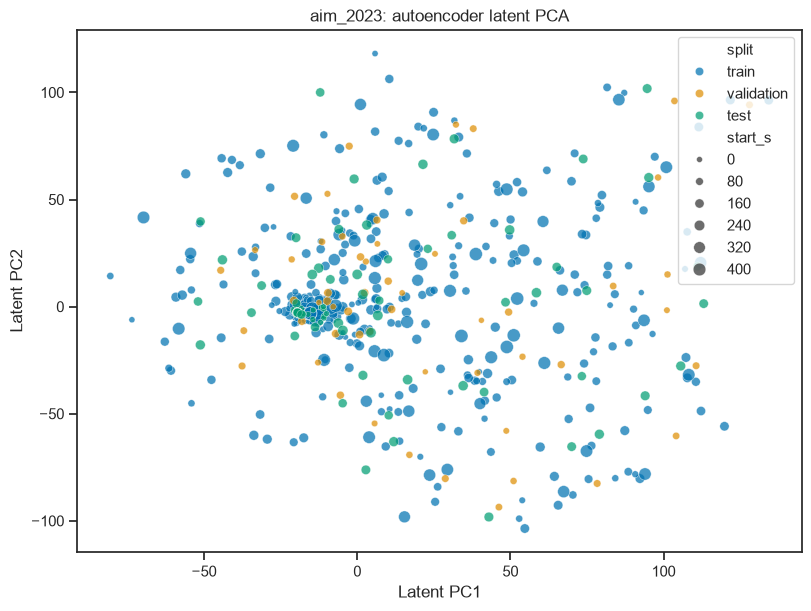

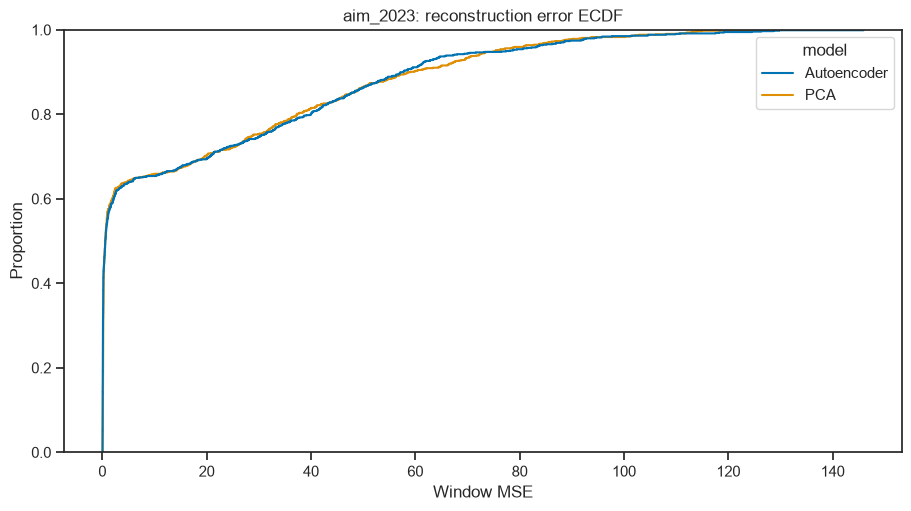

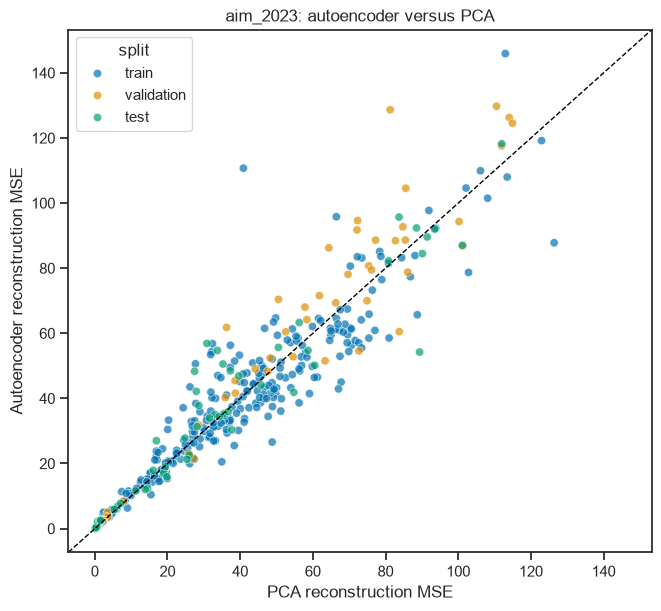

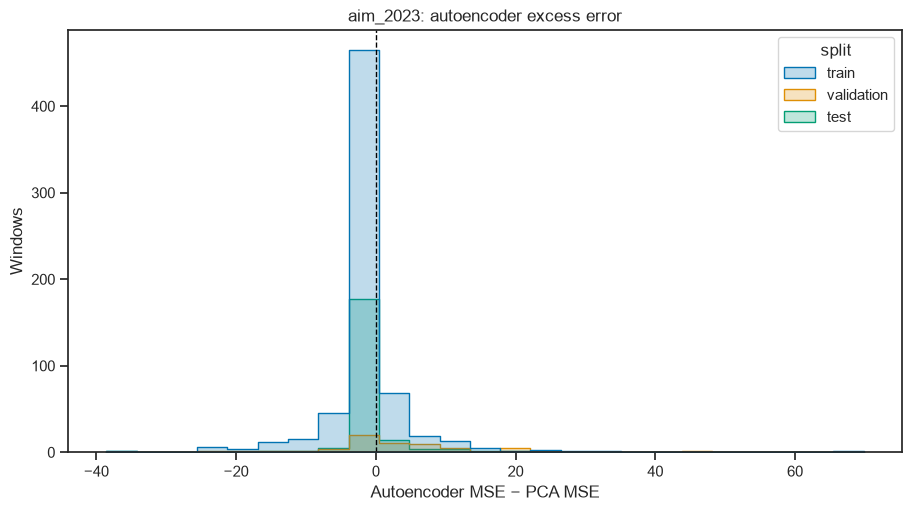

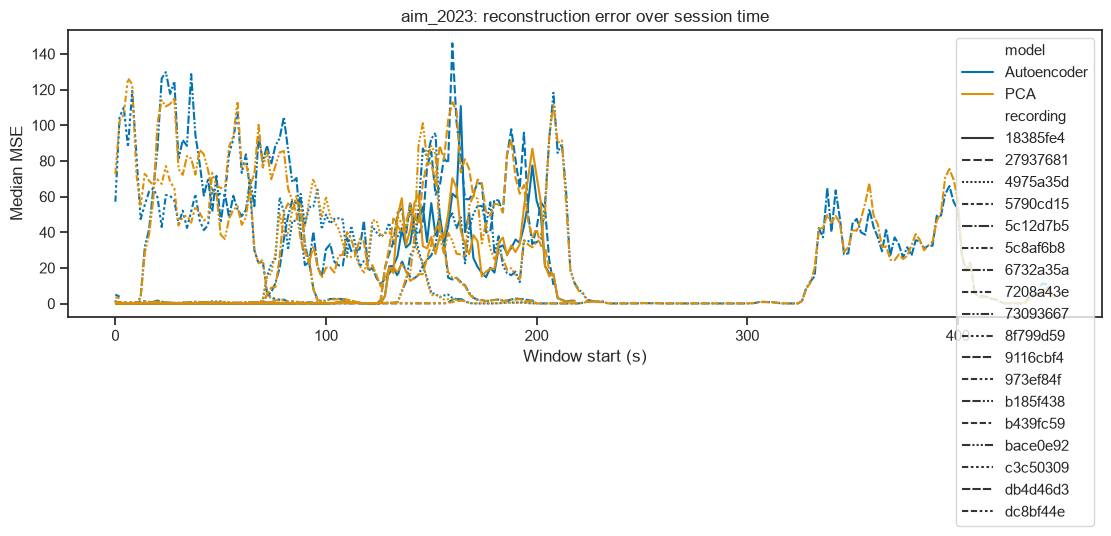

In [3]:
METHOD = "05_autoencoders"
result = run_experiment(METHOD, ROOT, dataset_key=DATASET_KEY, **EXPERIMENT_OPTIONS)
run_manifest = json.loads((result.output_dir / "manifest.json").read_text(encoding="utf-8"))
display(result.metrics)
display(result.predictions.describe(include="all").T)
display(result.predictions.groupby("recording_id")["score"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("median", ascending=False))
diagnostic_figures = render_autoencoder_diagnostics(result.predictions, run_manifest, result.output_dir)
for figure in diagnostic_figures.values():
    display(figure)
    plt.close(figure)

In [4]:
pd.Series(
    {
        "status": run_manifest["status"],
        "runtime_s": run_manifest["runtime_s"],
        "clock_provenance": run_manifest["data_provenance"]["clock_provenance"],
        "sample_rate_hz": run_manifest["data_provenance"]["native_sample_rate_hz"],
        "channels": run_manifest["data_provenance"]["selected_channels"],
        "label_provenance": run_manifest["label_provenance"],
    },
    name="value",
).to_frame()

,value
status,complete
runtime_s,5.572
clock_provenance,inferred_uniform_from_metadata
sample_rate_hz,20.0
channels,"[InlineAcc, LateralAcc, RollRate, PitchRate, Y..."
label_provenance,reconstruction_score_unverified


## Reading

Lower error than PCA supports representation efficiency only. Anomalies are not boundaries.

No lap precision, recall, count error, or duration error can be reported without independently reviewed boundaries.